# AI Burnout and Attrition data preprocessing

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

## Data loading

In [2]:
# Data has been extracted from "https://www.kaggle.com/datasets/nudratabbas/ai-worker-burnout-and-attrition-risk-dataset"

df = pd.read_csv('../data/ai_worker_burnout_attrition_2026.csv')

In [3]:
df.head()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium


In [4]:
df = df.drop(columns=['employee_id'], axis=1)

In [5]:
print('Dataset shape: {} rows, {} columns'.format(df.shape[0], df.shape[1]))

Dataset shape: 1500 rows, 20 columns


In [6]:
df.dtypes

job_role                           object
years_experience                    int64
education_level                    object
country                            object
industry                           object
company_size                       object
remote_work_type                   object
team_size                           int64
salary_usd_k                        int64
primary_ai_tool                    object
ai_tools_used_per_day               int64
hours_with_ai_assistance_daily    float64
ai_replaces_my_tasks_pct            int64
ai_adoption_stage                  object
weekly_ai_upskilling_hrs          float64
productivity_score                  int64
burnout_score                       int64
job_satisfaction_1_5              float64
fear_of_ai_replacement             object
attrition_risk                     object
dtype: object

## Data cleaning

In [7]:
print('Missing values: ')
print(df.isnull().sum())

Missing values: 
job_role                          0
years_experience                  0
education_level                   0
country                           0
industry                          0
company_size                      0
remote_work_type                  0
team_size                         0
salary_usd_k                      0
primary_ai_tool                   0
ai_tools_used_per_day             0
hours_with_ai_assistance_daily    0
ai_replaces_my_tasks_pct          0
ai_adoption_stage                 0
weekly_ai_upskilling_hrs          0
productivity_score                0
burnout_score                     0
job_satisfaction_1_5              0
fear_of_ai_replacement            0
attrition_risk                    0
dtype: int64


In [8]:
print('Contains duplicates?')
print(df.duplicated().any())

Contains duplicates?
False


## Exploratory Data Analysis

In [9]:
# Suggested questions by the author

# Does higher AI tool usage increase productivity or burnout — or both?

# Which job roles feel most threatened by AI replacement?

# Do remote workers experience different burnout patterns?

# Is there a "sweet spot" of AI usage that maximizes productivity without burnout?

# How does company size affect AI adoption and employee attrition risk?

### Does higher AI tool usage increase productivity or burnout — or both?

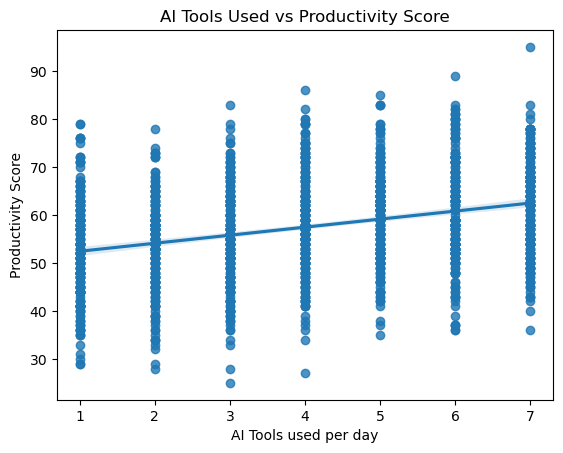

In [10]:
sns.regplot(
    x='ai_tools_used_per_day',
    y='productivity_score',
    data=df
)
plt.title('AI Tools Used vs Productivity Score')
plt.xlabel('AI Tools used per day')
plt.ylabel('Productivity Score')
plt.show()

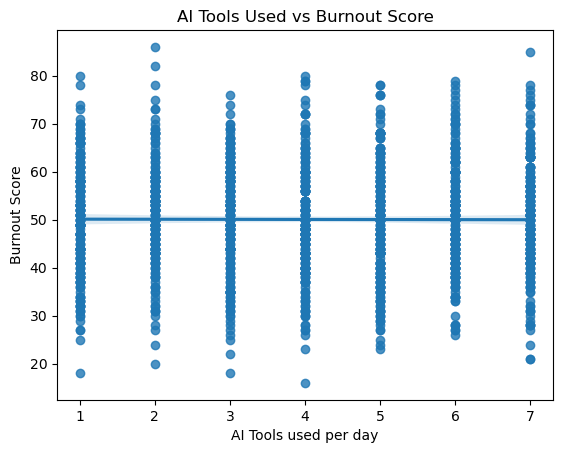

In [11]:
sns.regplot(
    x='ai_tools_used_per_day',
    y='burnout_score',
    data=df
)
plt.title('AI Tools Used vs Burnout Score')
plt.xlabel('AI Tools used per day')
plt.ylabel('Burnout Score')
plt.show()

Text(0.5, 1.0, 'Productivity by AI Tool usage')

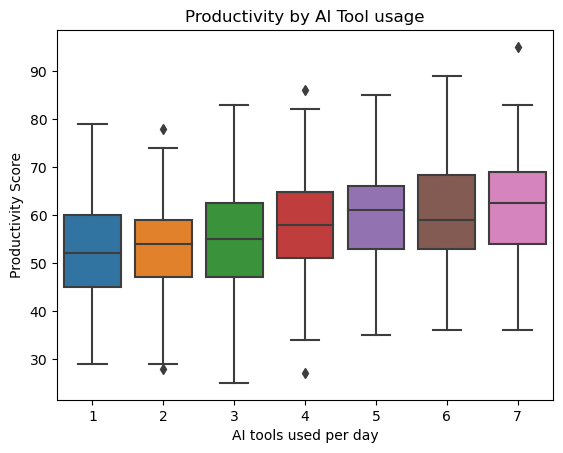

In [12]:
sns.boxplot(
    x='ai_tools_used_per_day',
    y='productivity_score',
    data=df
)
plt.xlabel('AI tools used per day')
plt.ylabel('Productivity Score')
plt.title('Productivity by AI Tool usage')

Text(0.5, 1.0, 'Burnout by AI Tool usage')

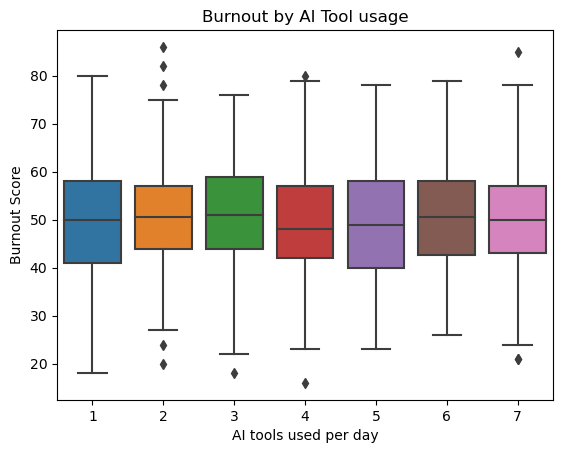

In [13]:
sns.boxplot(
    x='ai_tools_used_per_day',
    y='burnout_score',
    data=df
)
plt.xlabel('AI tools used per day')
plt.ylabel('Burnout Score')
plt.title('Burnout by AI Tool usage')

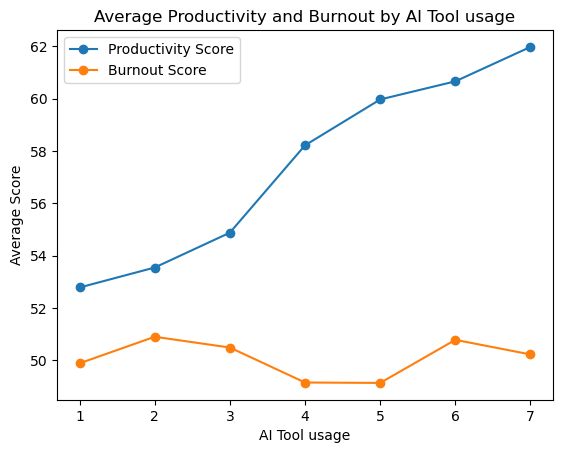

In [14]:
df.groupby('ai_tools_used_per_day')[['productivity_score', 'burnout_score']].mean().plot(marker='o')
plt.title('Average Productivity and Burnout by AI Tool usage')
plt.xlabel('AI Tool usage')
plt.ylabel('Average Score')
plt.legend(["Productivity Score", "Burnout Score"])
plt.show()

<Axes: >

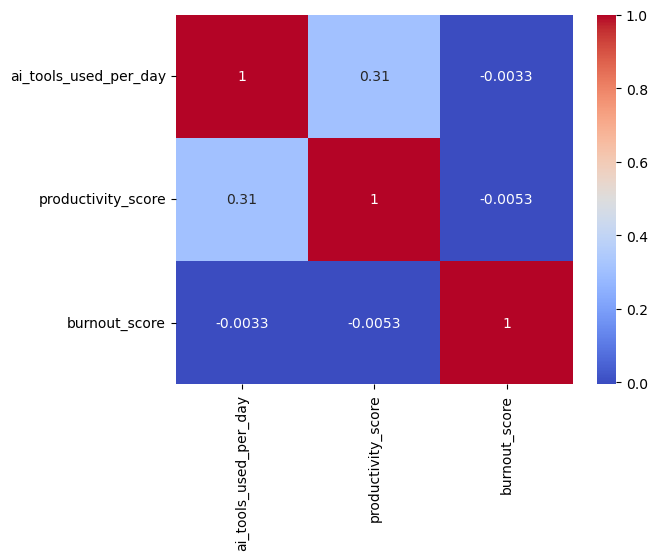

In [15]:
sns.heatmap(df[['ai_tools_used_per_day', 'productivity_score', 'burnout_score']].corr(), annot=True, cmap='coolwarm')

In [16]:
# The regression plot for productivity against ai tool usage shows a positive 
# trend, indicating that using more tools increases productivity.
# However, for the burnout regression plot against tool usage, it shows a 
# horizontal line, meaning that tool usage does not affect the burnout score.
# This is further reinforced by the line chart , indicating that using more tools
# does not mean an increased score for burnout.
# The correlation heatmap shows that productivity score has a positive correlation
# with AI tool usage, while burnout has a negatively weak correlation.

### Which job roles feel most threatened by AI replacement?

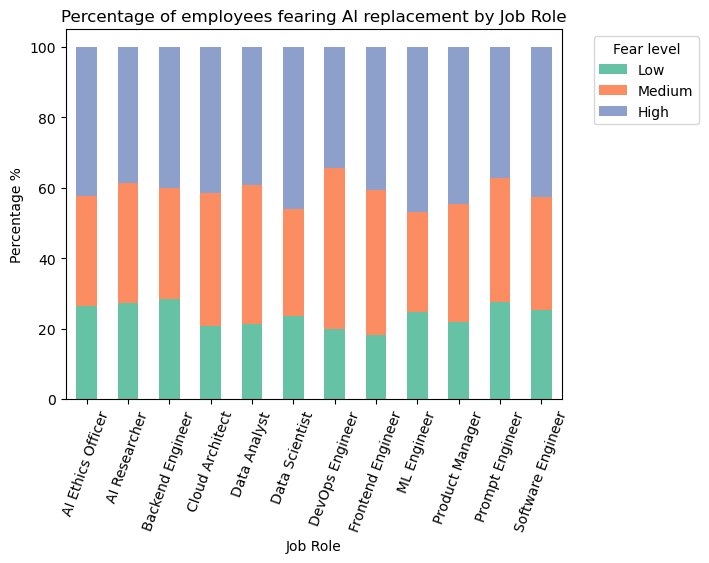

In [17]:
fear_count = pd.crosstab(df['job_role'], df['fear_of_ai_replacement'], normalize='index') * 100

colours = sns.color_palette('Set2')

fear_count.plot(kind='bar', stacked=True, color=colours)
plt.title('Percentage of employees fearing AI replacement by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Percentage %')
plt.legend(title='Fear level', 
           labels=['Low', 'Medium', 'High'], 
           bbox_to_anchor=(1.05, 1),
           loc='upper left'
)
plt.xticks(rotation=70)
plt.show()

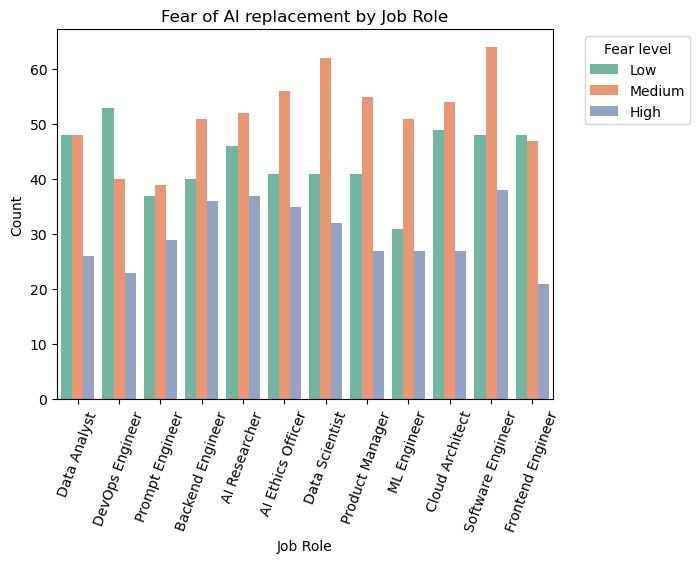

In [18]:
sns.countplot(x='job_role', hue='fear_of_ai_replacement', data=df, palette=colours)

plt.title('Fear of AI replacement by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Count')
plt.legend(title='Fear level', 
           labels=['Low', 'Medium', 'High'], 
           bbox_to_anchor=(1.05, 1),
           loc='upper left'
)
plt.xticks(rotation=70)
plt.show()

In [19]:
# The bar charts show that people are in the middle level of fear when it comes
# to AI replacing their jobs. In particular, software engineers have the highest
# count of "High" and "Medium" level of fear. Data scientists and AI researchers
# also have a high "Medium" and "High" level of fear respectively.
# So, roles involving repetitive or automable tasks tend to show higher perceived
# risk, as well as research type roles where AI can find sources more quickly
# can be considered at great risk. Roles that require strategic planning and
# being able to interpret data, as well as creative roles (like Frontend Engineer),
# are considered less at risk.

### Do remote workers experience different burnout patterns?

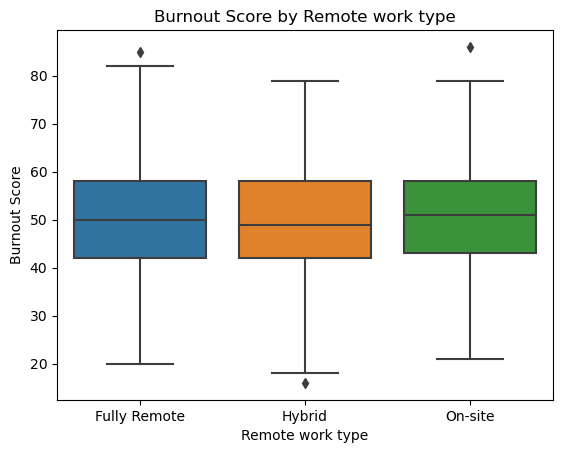

In [20]:
sns.boxplot(x='remote_work_type', y='burnout_score', data=df)

plt.title('Burnout Score by Remote work type')
plt.xlabel('Remote work type')
plt.ylabel('Burnout Score')
plt.show()

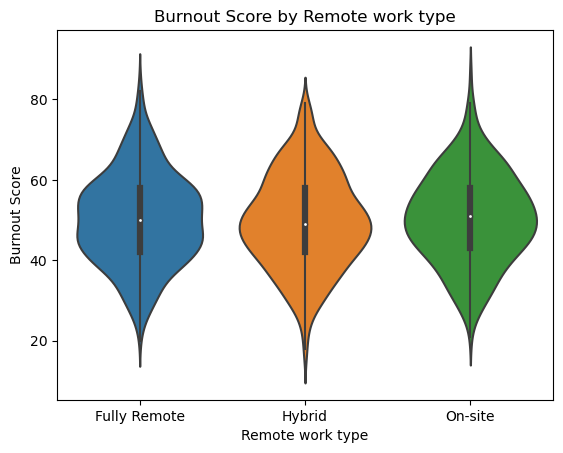

In [21]:
sns.violinplot(x='remote_work_type', y='burnout_score', data=df)

plt.title('Burnout Score by Remote work type')
plt.xlabel('Remote work type')
plt.ylabel('Burnout Score')
plt.show()

In [22]:
# The box plot and violin plot show that the location where the work is being
# done, whether in person or remote, does not matter. The burnout scores among 
# the three different work types show very similar results.

### Is there a "sweet spot" of AI usage that maximizes productivity without burnout?

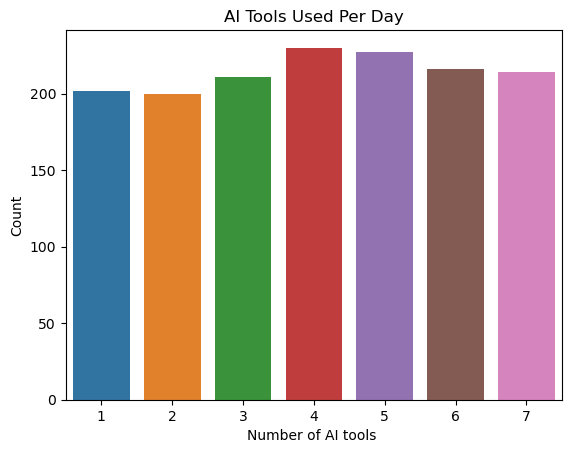

In [23]:
sns.countplot(x='ai_tools_used_per_day', data=df)
plt.title('AI Tools Used Per Day')
plt.xlabel('Number of AI tools ')
plt.ylabel('Count')
plt.show()

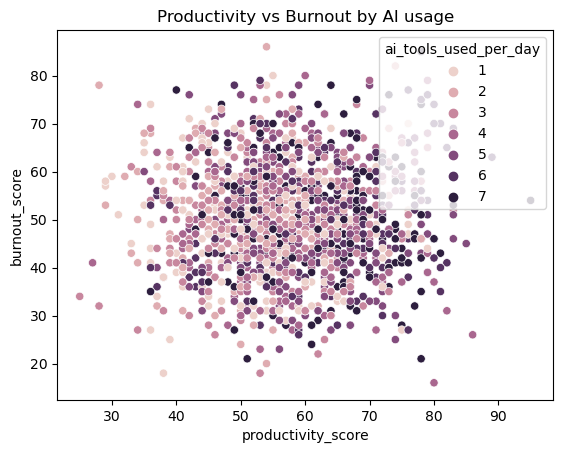

In [24]:
sns.scatterplot(
    x='productivity_score',
    y='burnout_score',
    hue='ai_tools_used_per_day',
    data=df
)

plt.title('Productivity vs Burnout by AI usage')
plt.show()

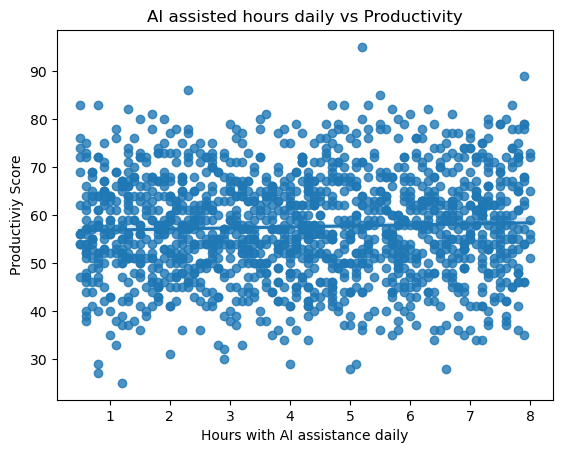

In [25]:
sns.regplot(
    x='hours_with_ai_assistance_daily',
    y='productivity_score',
    data=df
)
plt.title('AI assisted hours daily vs Productivity')
plt.xlabel('Hours with AI assistance daily')
plt.ylabel('Productiviy Score')
plt.show()

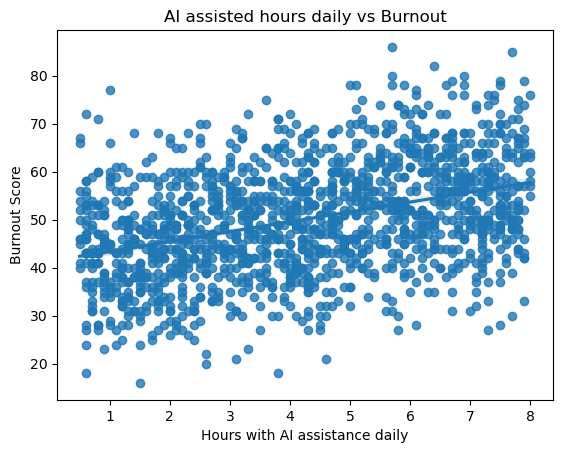

In [26]:
sns.regplot(
    x='hours_with_ai_assistance_daily',
    y='burnout_score',
    data=df
)
plt.title('AI assisted hours daily vs Burnout')
plt.xlabel('Hours with AI assistance daily')
plt.ylabel('Burnout Score')
plt.show()

In [27]:
# As shown in the first question, the sweet spot should be using 5 AI tools per
# day. The regression plot for productivity against hours spent using AI shows 
# very scattered data points, meaning that there is no clear trend with increased
# productivity the more someone uses AI tools. However, the regression plot for
# burnout against hours spent using AI shows a positive updward trend, meaning
# that burnout increases the more the user uses AI. This is possibly due to 
# cognitive overload or increased expectations.
# These findings indicate that moderate AI tool diversity may enhance productivity,
# while excessive time spent working with AI tools may increase burnout risk.

### How does company size affect AI adoption and employee attrition risk?

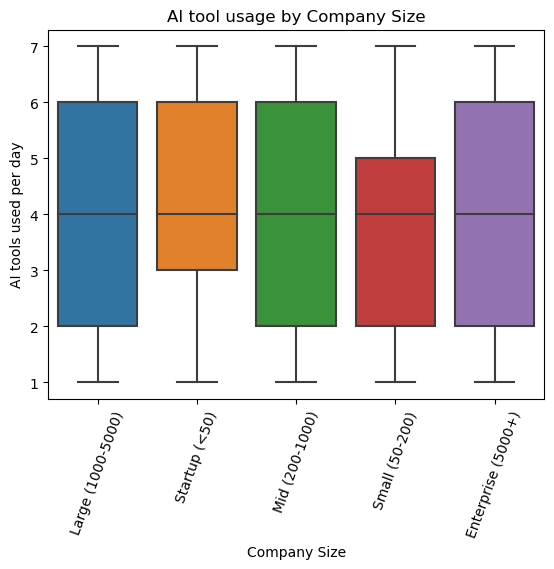

In [28]:
sns.boxplot(x='company_size', y='ai_tools_used_per_day', data=df)

plt.title('AI tool usage by Company Size')
plt.xlabel('Company Size')
plt.ylabel('AI tools used per day')
plt.xticks(rotation=70)
plt.show()

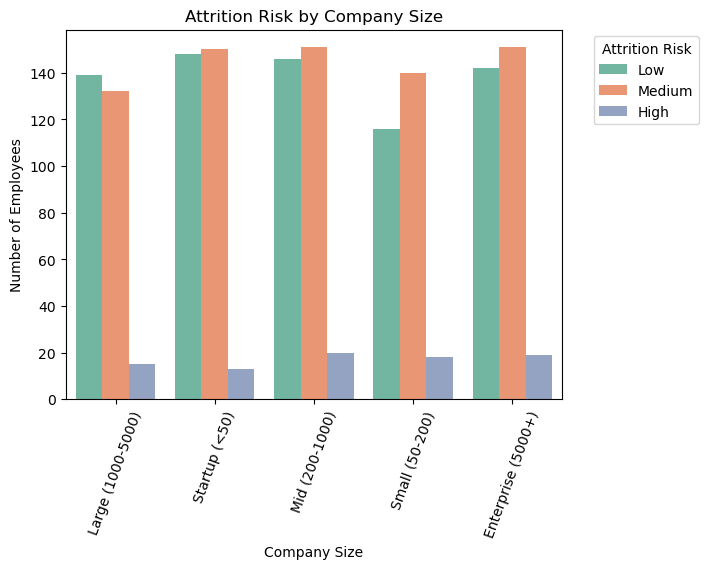

In [29]:
sns.countplot(x='company_size', hue='attrition_risk', data=df, palette='Set2')

plt.title('Attrition Risk by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Number of Employees')
plt.legend(title='Attrition Risk', 
           labels=['Low', 'Medium', 'High'], 
           bbox_to_anchor=(1.05, 1)
)
plt.xticks(rotation=70)
plt.show()

In [30]:
# The analysis here shows that larger companies tend to use AI tools consistently.
# Smaller companies and startups show some variability. Some startups appear to
# use AI tools more than small companies, which may reflect differences in 
# organizational structure rather than an anomaly.
# The attrition risk is between Low and Medium for most sizes, meaning that 
# company size does not make employees leave. This is because company size 
# alone does not appear to strongly influence attrition risk. Other variables,
# such as job satisfaction and burnout score may play a significant role.

### Other visualizations

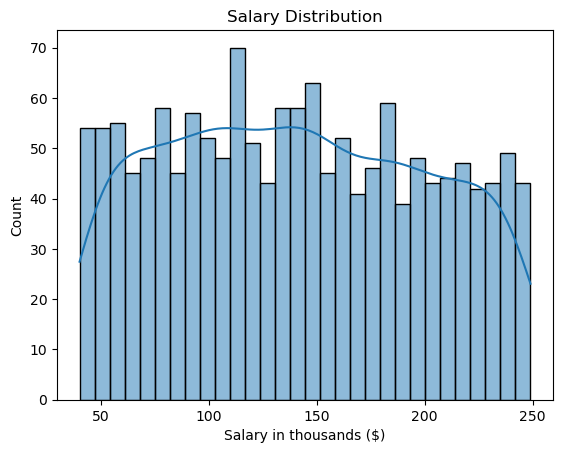

In [31]:
sns.histplot(df['salary_usd_k'], kde=True, bins=30)
plt.title('Salary Distribution')
plt.xlabel('Salary in thousands ($)')
plt.ylabel('Count')
plt.show()

In [32]:
# Roles in technology tend to have similar salaries.

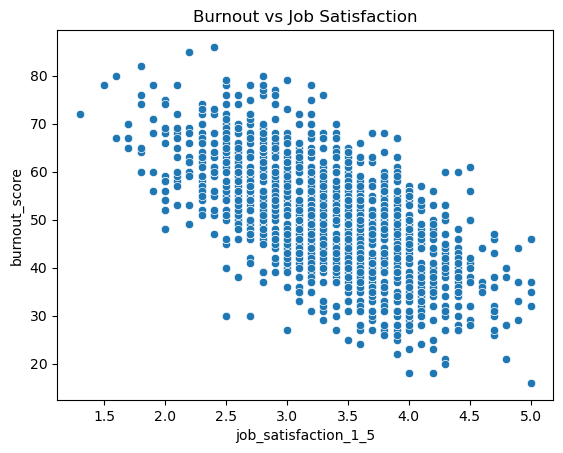

In [33]:
sns.scatterplot(
    x='job_satisfaction_1_5',
    y='burnout_score',
    data=df
)
plt.title('Burnout vs Job Satisfaction')
plt.show()

In [34]:
# Higher job role satisfaction shows that people will burnout less.

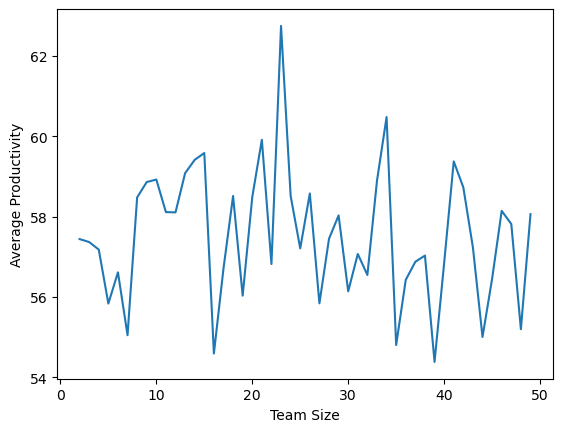

In [35]:
df.groupby('team_size')['productivity_score'].mean().plot()
plt.xlabel('Team Size')
plt.ylabel('Average Productivity')
plt.show()

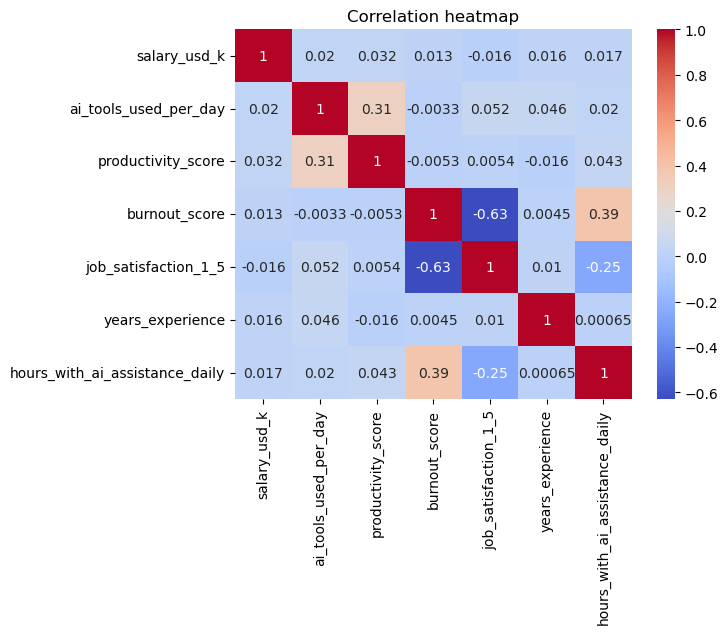

In [36]:
num_cols = df[['salary_usd_k', 'ai_tools_used_per_day', 'productivity_score', 
                'burnout_score', 'job_satisfaction_1_5', 'years_experience',
                'hours_with_ai_assistance_daily']]

sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

## Statistical Analysis

### Group comparisons (Categorical vs Numeric)
Test if numeric outcomes differ across groups

### ANOVA test

Null hypothesis: no significant differences 

Alternate hypothesis: at least one group mean is different

In [37]:
from scipy.stats import f_oneway

# Groups are Remote, On-site, and Hybrid
groups = [df[df['remote_work_type']==mode]['burnout_score'] for mode in df['remote_work_type'].unique()]

f_stat, p_val = f_oneway(*groups)

print(f"F-statistic = {f_stat}, p-value = {p_val}")

F-statistic = 0.7994858703998953, p-value = 0.4497518909059943


<Axes: xlabel='remote_work_type', ylabel='burnout_score'>

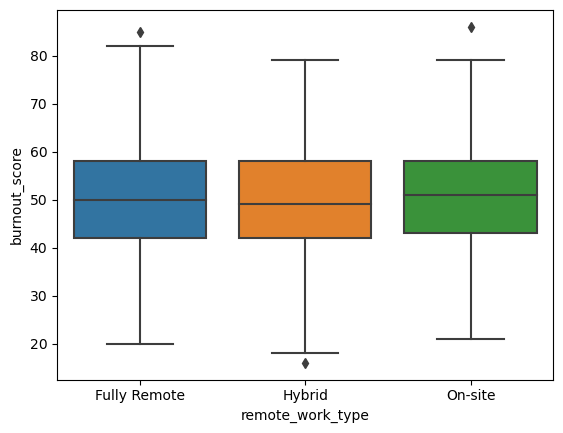

In [38]:
sns.boxplot(x='remote_work_type', y='burnout_score', data=df)

In [39]:
# p-value is greater than 0.05, therefore accept null hypothesis.
# Burnout scores do not differ across work modes (Remote, On-site, Hybrid).

In [40]:
groups = [df[df['company_size']==mode]['productivity_score'] for mode in df['company_size'].unique()]

f_stat, p_val = f_oneway(*groups)

print(f"F-statistic = {f_stat}, p-value = {p_val}")

F-statistic = 0.6423817169133733, p-value = 0.6323176461598108


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Large (1000-5000)'),
  Text(1, 0, 'Startup (<50)'),
  Text(2, 0, 'Mid (200-1000)'),
  Text(3, 0, 'Small (50-200)'),
  Text(4, 0, 'Enterprise (5000+)')])

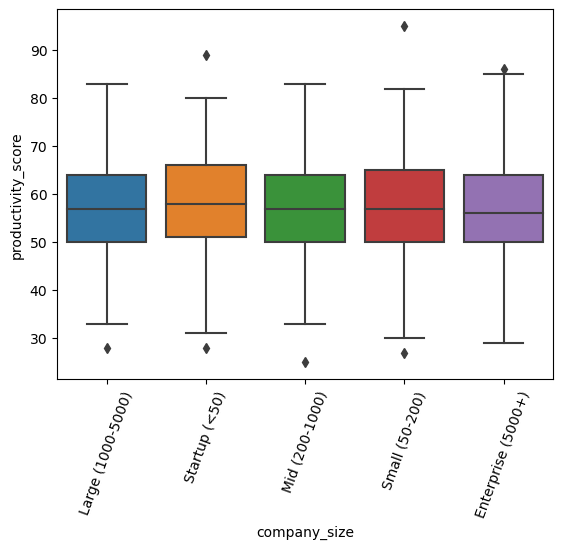

In [41]:
sns.boxplot(x='company_size', y='productivity_score', data=df)

plt.xticks(rotation=70)

In [42]:
# p-value is greater than 0.05, therefore accept null hypothesis
# Productivity scores do not differ across different company sizes 

### Chi-Square Test (Categorical vs Categorical)
Check if two categorical variables are independent

Null hypothesis: company size and attrition are independent variables

Alternate hypothesis: company size and attrition are associated

In [43]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['company_size'], df['attrition_risk'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2 = {chi2}, p-value = {p}")

Chi2 = 4.176177212269439, p-value = 0.8408884663198247


In [44]:
# p-value is greater than 0.05, therefore accept null hypothesis
# No statistically significant association between company size and attrition 
# risk

Null hypothesis: fear of ai replacement and job role are independent

Alternate hypothesis: fear of ai replacement and job role are associated

In [45]:
contingency_table = pd.crosstab(df['fear_of_ai_replacement'], df['job_role'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2 = {chi2}, p-value = {p}")

Chi2 = 20.34253319417209, p-value = 0.5616229619197378


In [46]:
# p-value is greater than 0.05, therefore accept null hypothesis

## Regression Analysis

In [47]:
import statsmodels.api as sm

X = df[['ai_tools_used_per_day', 'hours_with_ai_assistance_daily']]
y = df['productivity_score']
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     productivity_score   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     79.85
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           1.12e-33
Time:                        17:59:47   Log-Likelihood:                -5611.0
No. Observations:                1500   AIC:                         1.123e+04
Df Residuals:                    1497   BIC:                         1.124e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [48]:
# For each additional AI tool used per day, productivity increases by about 1.67
# points on average, because p value is less than 0.05.
# This shows that AI tool usage has a statistically significant positive 
# relationship with productivity.
# Furthermore, hours with AI assitance resulted in a coefficient of 0.184, which
# is greater than 0.05, and so it is not statistically significant.

In [49]:
X = df[['ai_tools_used_per_day', 'hours_with_ai_assistance_daily']]
y = df['burnout_score']
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          burnout_score   R-squared:                       0.149
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     130.9
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           4.22e-53
Time:                        17:59:47   Log-Likelihood:                -5662.5
No. Observations:                1500   AIC:                         1.133e+04
Df Residuals:                    1497   BIC:                         1.135e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [50]:
# This analysis shows that AI tool usage is not stastically significant against
# burnout score.
# Furthermore, p-value is less than 0.05 for hours with AI assistance, meaning
# that this variable is statistically significant.

In [51]:
# The second OLS regression model was statistically significant 
# (F = 130.9, p < 0.001) and explained approximately 14.9% of the variance in 
# burnout scores.

# The first model was also statistically significant (F = 78.95, p < 0.001),
# indicating that the predictors collectively explain variation in productivity
# scores. The model, however, explained a relatively small proportion of the 
# variance (R-squared = 0.096), meaning that AI usage accounts for 9.6% of productivity
# difference among employees.